In [7]:
import pandas as pd
import pickle
from sklearn.metrics import accuracy_score, classification_report
import re
import numpy as np
import tldextract
from urllib.parse import urlparse

# --------------------------
# Load trained model pipeline
# --------------------------
with open("phishing_detector_v2.pkl", "rb") as f:
    model = pickle.load(f)

# --------------------------
# Load test dataset
# --------------------------
df = pd.read_csv("dataset_phishing.csv")

# FIX: rename URL → url so model gets correct column
df = df.rename(columns={"URL": "url"})

# Label column
label_column = "status"
y_test = df[label_column].astype(int)

# --------------------------
# Feature extraction functions (same as training)
# --------------------------
def entropy(s):
    if not s: return 0
    probs = [s.count(c) / len(s) for c in set(s)]
    return -sum(p * np.log2(p) for p in probs)

def extract_features(url):
    url = str(url).strip()
    parsed = urlparse(url)
    ext = tldextract.extract(url)

    domain = ext.domain
    sub = ext.subdomain
    path = parsed.path
    query = parsed.query

    brands = ["paypal", "google", "amazon", "microsoft", "netflix", "apple", "facebook", "bank"]
    brand_spoof = any(brand in url.lower() and brand != domain for brand in brands)

    return pd.Series({
        "url_length": len(url),
        "domain_length": len(domain),
        "path_length": len(path),
        "digits_in_url": sum(c.isdigit() for c in url),
        "special_chars": len(re.findall(r"[^A-Za-z0-9]", url)),
        "count_-": url.count("-"),
        "count_.": url.count("."),
        "count_/": url.count("/"),
        "count_?": url.count("?"),
        "count_=": url.count("="),
        "num_subdomains": len(sub.split(".")) if sub else 0,
        "has_https": int(parsed.scheme == "https"),
        "query_params": len(query.split("&")) if query else 0,
        "contains_ip": int(bool(re.match(r"^\d{1,3}(\.\d{1,3}){3}$", domain))),
        "is_punycode": int("xn--" in url),
        "brand_spoof": int(brand_spoof),
        "entropy": entropy(url),
        "has_login": int("login" in url.lower()),
        "has_secure": int("secure" in url.lower()),
        "has_update": int("update" in url.lower()),
        "has_verify": int("verify" in url.lower()),
    })

# --------------------------
# Generate numeric features
# --------------------------
feature_df = df["url"].apply(extract_features)

# Merge into test frame
test_df = pd.concat([df, feature_df], axis=1)

# --------------------------
# Predict (IMPORTANT: model expects column "url")
# --------------------------
y_pred = model.predict(test_df[["url"] + list(feature_df.columns)])

# --------------------------
# Output metrics
# --------------------------
print("\n--- TEST SET PERFORMANCE ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# --------------------------
# Save predictions
# --------------------------
test_df["predicted_label"] = y_pred
test_df.to_csv("test_predictions.csv", index=False)

print("\n✔ Predictions saved as test_predictions.csv")


--- TEST SET PERFORMANCE ---
Accuracy: 0.5020997375328085
              precision    recall  f1-score   support

           0       0.85      0.01      0.01      5715
           1       0.50      1.00      0.67      5715

    accuracy                           0.50     11430
   macro avg       0.68      0.50      0.34     11430
weighted avg       0.68      0.50      0.34     11430


✔ Predictions saved as test_predictions.csv


In [1]:
import pandas as pd
import pickle
import re
import numpy as np
import tldextract
from urllib.parse import urlparse
from collections import Counter
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------
# 1. Load trained model pipeline
# --------------------------
try:
    with open("phishing_detector_v2.pkl", "rb") as f:
        model = pickle.load(f)
except FileNotFoundError:
    print("Error: 'phishing_detector_v2.pkl' not found.")
    exit()

# --------------------------
# 2. Load test dataset
# --------------------------
df = pd.read_csv("dataset_phishing.csv")

# Fix: rename URL column if necessary
if "URL" in df.columns:
    df = df.rename(columns={"URL": "url"})

# Label mapping: Ensure this MATCHES your training (0 for Legit, 1 for Phishing)
# Adjust the keys below based on what is actually in 'dataset_phishing.csv'
label_map = {"legitimate": 0, "phishing": 1, 2: 0, 3: 1}
if "status" in df.columns:
    y_test = df["status"].map(label_map)
else:
    print("Error: 'status' column not found in dataset.")
    exit()

# --------------------------
# 3. Feature extraction (Optimized)
# --------------------------
def entropy(s):
    if not s: return 0
    counts = Counter(s)
    probs = [count / len(s) for count in counts.values()]
    return -sum(p * np.log2(p) for p in probs)

def extract_features(url):
    url = str(url).strip()
    parsed = urlparse(url)
    ext = tldextract.extract(url)
    domain, sub, path, query = ext.domain, ext.subdomain, parsed.path, parsed.query

    brands = ["paypal", "google", "amazon", "microsoft", "netflix", "apple", "facebook", "bank"]
    brand_spoof = any(brand in url.lower() and brand != domain for brand in brands)

    return pd.Series({
        "url_length": len(url),
        "domain_length": len(domain),
        "path_length": len(path),
        "digits_in_url": sum(c.isdigit() for c in url),
        "special_chars": len(re.findall(r"[^A-Za-z0-9]", url)),
        "count_-": url.count("-"),
        "count_.": url.count("."),
        "count_/": url.count("/"),
        "count_?": url.count("?"),
        "count_=": url.count("="),
        "num_subdomains": len(sub.split(".")) if sub else 0,
        "has_https": int(parsed.scheme == "https"),
        "query_params": len(query.split("&")) if query else 0,
        "contains_ip": int(bool(re.match(r"^\d{1,3}(\.\d{1,3}){3}$", domain))),
        "is_punycode": int("xn--" in url),
        "brand_spoof": int(brand_spoof),
        "entropy": entropy(url),
        "has_login": int("login" in url.lower()),
        "has_secure": int("secure" in url.lower()),
        "has_update": int("update" in url.lower()),
        "has_verify": int("verify" in url.lower()),
    })

# --------------------------
# 4. Process and Predict
# --------------------------
print("Extracting features from test set...")
feature_df = df["url"].apply(extract_features)

# Define the exact numeric column list used during training
numeric_cols = feature_df.columns.tolist()

# Combine into the specific format the pipeline expects: ["url"] + numeric_features
X_test = pd.concat([df[["url"]], feature_df], axis=1)

print("Running predictions...")
y_pred = model.predict(X_test)

# --------------------------
# 5. Output Metrics & Visualization
# --------------------------
print("\n--- TEST SET PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Legitimate", "Phishing"]))

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=["Predicted Legit", "Predicted Phish"],
            yticklabels=["Actual Legit", "Actual Phish"])
plt.title("Confusion Matrix: Phishing Detection")
plt.show()



# --------------------------
# 6. Save Results
# --------------------------
df["predicted_label"] = y_pred
df["is_correct"] = (df["predicted_label"] == y_test)
df.to_csv("test_predictions.csv", index=False)

print("\n✔ Detailed predictions saved as test_predictions.csv")

Extracting features from test set...
Running predictions...

--- TEST SET PERFORMANCE ---


C:\Users\91903\anaconda3\envs\nlp_course_env\Lib\site-packages\sklearn\utils\_array_api.py:392: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype, copy=copy, casting=casting)


ValueError: Input y_true contains NaN.

Loading model and dataset...
Original unique labels in 'status': [0 1]
Extracting features (this may take a moment)...
Running model predictions...

TEST SET PERFORMANCE
Accuracy Score: 0.5021

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.85      0.01      0.01      5715
    Phishing       0.50      1.00      0.67      5715

    accuracy                           0.50     11430
   macro avg       0.68      0.50      0.34     11430
weighted avg       0.68      0.50      0.34     11430



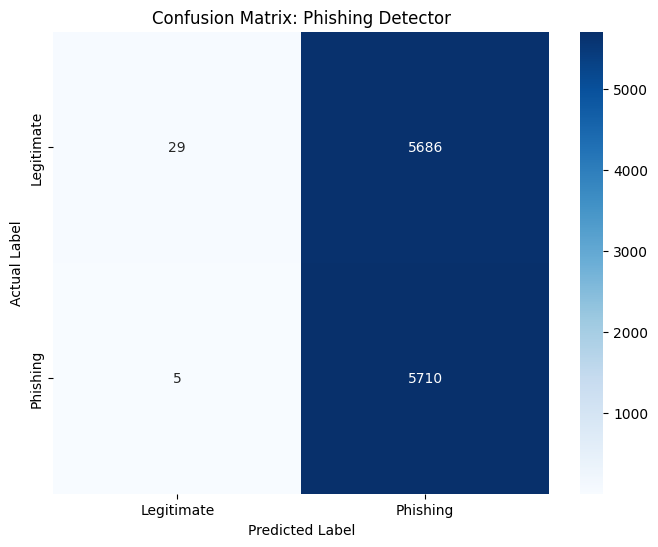


✔ Results saved to 'test_results_final.csv'


In [2]:
import pandas as pd
import numpy as np
import re
import pickle
import tldextract
from urllib.parse import urlparse
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ----------------------------------------------------------------------
# 1. HELPER FUNCTIONS (Optimized)
# ----------------------------------------------------------------------
def entropy(s):
    if not s: return 0
    counts = Counter(s)
    probs = [count / len(s) for count in counts.values()]
    return -sum(p * np.log2(p) for p in probs)

def extract_features(url):
    url = str(url).strip()
    parsed = urlparse(url)
    ext = tldextract.extract(url)

    domain = ext.domain
    sub = ext.subdomain
    path = parsed.path
    query = parsed.query
    
    brands = ["paypal", "google", "amazon", "microsoft", "netflix", "apple", "facebook", "bank"]
    brand_spoof = any(brand in url.lower() and brand != domain for brand in brands)

    return pd.Series({
        "url_length": len(url),
        "domain_length": len(domain),
        "path_length": len(path),
        "digits_in_url": sum(c.isdigit() for c in url),
        "special_chars": len(re.findall(r"[^A-Za-z0-9]", url)),
        "count_-": url.count("-"),
        "count_.": url.count("."),
        "count_/": url.count("/"),
        "count_?": url.count("?"),
        "count_=": url.count("="),
        "num_subdomains": len(sub.split(".")) if sub else 0,
        "has_https": int(parsed.scheme == "https"),
        "query_params": len(query.split("&")) if query else 0,
        "contains_ip": int(bool(re.match(r"^\d{1,3}(\.\d{1,3}){3}$", domain))),
        "is_punycode": int("xn--" in url),
        "brand_spoof": int(brand_spoof),
        "entropy": entropy(url),
        "has_login": int("login" in url.lower()),
        "has_secure": int("secure" in url.lower()),
        "has_update": int("update" in url.lower()),
        "has_verify": int("verify" in url.lower()),
    })

# ----------------------------------------------------------------------
# 2. LOAD MODEL & DATA
# ----------------------------------------------------------------------
print("Loading model and dataset...")
with open("phishing_detector_v2.pkl", "rb") as f:
    pipeline = pickle.load(f)

df = pd.read_csv("dataset_phishing.csv")

# Standardize column name
if "URL" in df.columns:
    df = df.rename(columns={"URL": "url"})

# --- IMPORTANT: FIXING THE NaN ERROR ---
# This map covers common label formats found in phishing datasets
label_map = {
    "legitimate": 0, "phishing": 1, 
    "legit": 0, "phish": 1,
    "0": 0, "1": 1, 
    0: 0, 1: 1, 
    2: 0, 3: 1
}

print(f"Original unique labels in 'status': {df['status'].unique()}")
df["label_cleaned"] = df["status"].map(label_map)

# Drop any rows that didn't match the map (prevents the NaN ValueError)
initial_len = len(df)
df = df.dropna(subset=["label_cleaned"])
if len(df) < initial_len:
    print(f"⚠ Dropped {initial_len - len(df)} rows due to unmapped labels.")

y_test = df["label_cleaned"].astype(int)

# ----------------------------------------------------------------------
# 3. FEATURE EXTRACTION & PREDICTION
# ----------------------------------------------------------------------
print("Extracting features (this may take a moment)...")
feature_df = df["url"].apply(extract_features)

# Reconstruct the feature matrix to match the Pipeline's expected order
numeric_features = feature_df.columns.tolist()
X_test = pd.concat([df[["url"]], feature_df], axis=1)

print("Running model predictions...")
y_pred = pipeline.predict(X_test)

# ----------------------------------------------------------------------
# 4. EVALUATION & VISUALIZATION
# ----------------------------------------------------------------------
print("\n" + "="*30)
print("TEST SET PERFORMANCE")
print("="*30)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Legitimate", "Phishing"]))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legitimate', 'Phishing'], 
            yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix: Phishing Detector')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()



# Save results
df["predicted"] = y_pred
df.to_csv("test_results_final.csv", index=False)
print("\n✔ Results saved to 'test_results_final.csv'")